In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# load data set
df = pd.read_csv('../Sonar-Signal-Classification/Data_set/sonar.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,0.0881,0.1992,0.0184,0.2261,0.1729,0.2131,0.0693,0.2281,0.4060,0.3973,0.2741,0.3690,0.5556,0.4846,0.3140,0.5334,0.5256,0.2520,0.2090,0.3559,0.6260,0.7340,0.6120,0.3497,0.3953,0.3012,0.5408,0.8814,0.9857,0.9167,0.6121,0.5006,0.3210,0.3202,0.4295,0.3654,0.2655,0.1576,0.0681,0.0294,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [3]:
df.shape

(208, 61)

In [4]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-null    float64
 22  22

In [5]:
df.isnull().sum()

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Length: 61, dtype: int64

In [6]:
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60],
      dtype='int64')

In [ ]:
# check unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

0: [0.02   0.0453 0.0262 0.01   0.0762 0.0286 0.0317 0.0519 0.0223 0.0164
 0.0039 0.0123 0.0079 0.009  0.0124 0.0298 0.0352 0.0192 0.027  0.0126
 0.0473 0.0664 0.0099 0.0115 0.0293 0.0201 0.0151 0.0177 0.0189 0.024
 0.0084 0.0195 0.0442 0.0311 0.0206 0.0094 0.0333 0.0091 0.0068 0.0093
 0.0211 0.0257 0.0408 0.0308 0.0373 0.019  0.0119 0.0353 0.0131 0.0087
 0.0132 0.0152 0.0216 0.0225 0.0125 0.013  0.0135 0.0086 0.0067 0.0071
 0.0176 0.0265 0.0368 0.0065 0.0036 0.0208 0.0139 0.0109 0.0202 0.0239
 0.0336 0.0231 0.0108 0.0229 0.0409 0.0217 0.0378 0.0365 0.0188 0.0856
 0.0274 0.0235 0.0253 0.026  0.0459 0.0025 0.0291 0.0181 0.0491 0.1313
 0.0629 0.0335 0.0587 0.0162 0.0307 0.0116 0.0331 0.0428 0.0599 0.0264
 0.021  0.053  0.0454 0.0283 0.0114 0.0414 0.0228 0.0363 0.0261 0.0346
 0.0249 0.0388 0.0715 0.0209 0.0374 0.1371 0.0443 0.115  0.0968 0.079
 0.1083 0.1088 0.043  0.0731 0.0412 0.0707 0.0526 0.0516 0.0299 0.0721
 0.1021 0.0654 0.0712 0.0207 0.0233 0.0117 0.0047 0.0107 0.0258 0.0305
 0.00

In [8]:
print (df[60].value_counts(normalize=True)* 100)


60
M    53.365385
R    46.634615
Name: proportion, dtype: float64


In [ ]:
# map R to 0 and M to 1
df[60] = df[60].map({'R': 0, 'M': 1})

In [11]:
print (df[60].value_counts(normalize=True)* 100)

60
1    53.365385
0    46.634615
Name: proportion, dtype: float64


In [13]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
n_row=len
nuinique=df.nunique()

constant_cols=nuinique[nuinique == 1].index.tolist()
print(f"Constant columns: {constant_cols}")

quasi_constant_cols=[]

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        quasi_constant_cols.append(col)

print(f"Quasi-constant columns: {quasi_constant_cols}")


Constant columns: []
Quasi-constant columns: []


In [17]:
# display all columns
pd.set_option('display.max_columns', None)

In [18]:
# group by target variable and calculate mean of each feature
grouped = df.groupby(60).mean()
print(grouped)

          0         1         2         3         4         5         6   \
60                                                                         
0   0.022498  0.030303  0.035951  0.041447  0.062028  0.096224  0.114180   
1   0.034989  0.045544  0.050720  0.064768  0.086715  0.111864  0.128359   

          7         8         9         10        11        12        13  \
60                                                                         
0   0.117596  0.137392  0.159325  0.174713  0.191589  0.226249  0.268963   
1   0.149832  0.213492  0.251022  0.289581  0.301459  0.314426  0.320692   

          14        15        16        17        18        19        20  \
60                                                                         
0   0.307636  0.375611  0.417100  0.448240  0.466762  0.500229  0.542270   
1   0.331182  0.380999  0.415007  0.455882  0.538062  0.617941  0.667426   

          21        22        23        24        25        26        27  \
60       

In [19]:
# display summary statistics
print(df.describe())

               0           1           2           3           4           5   \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.382300   

               6           7           8           9           10          11  \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.121747    0.134799    0.178003    0.208259    0.236013    0.250221   
std      0.061788    0.0851

### Data Visualization

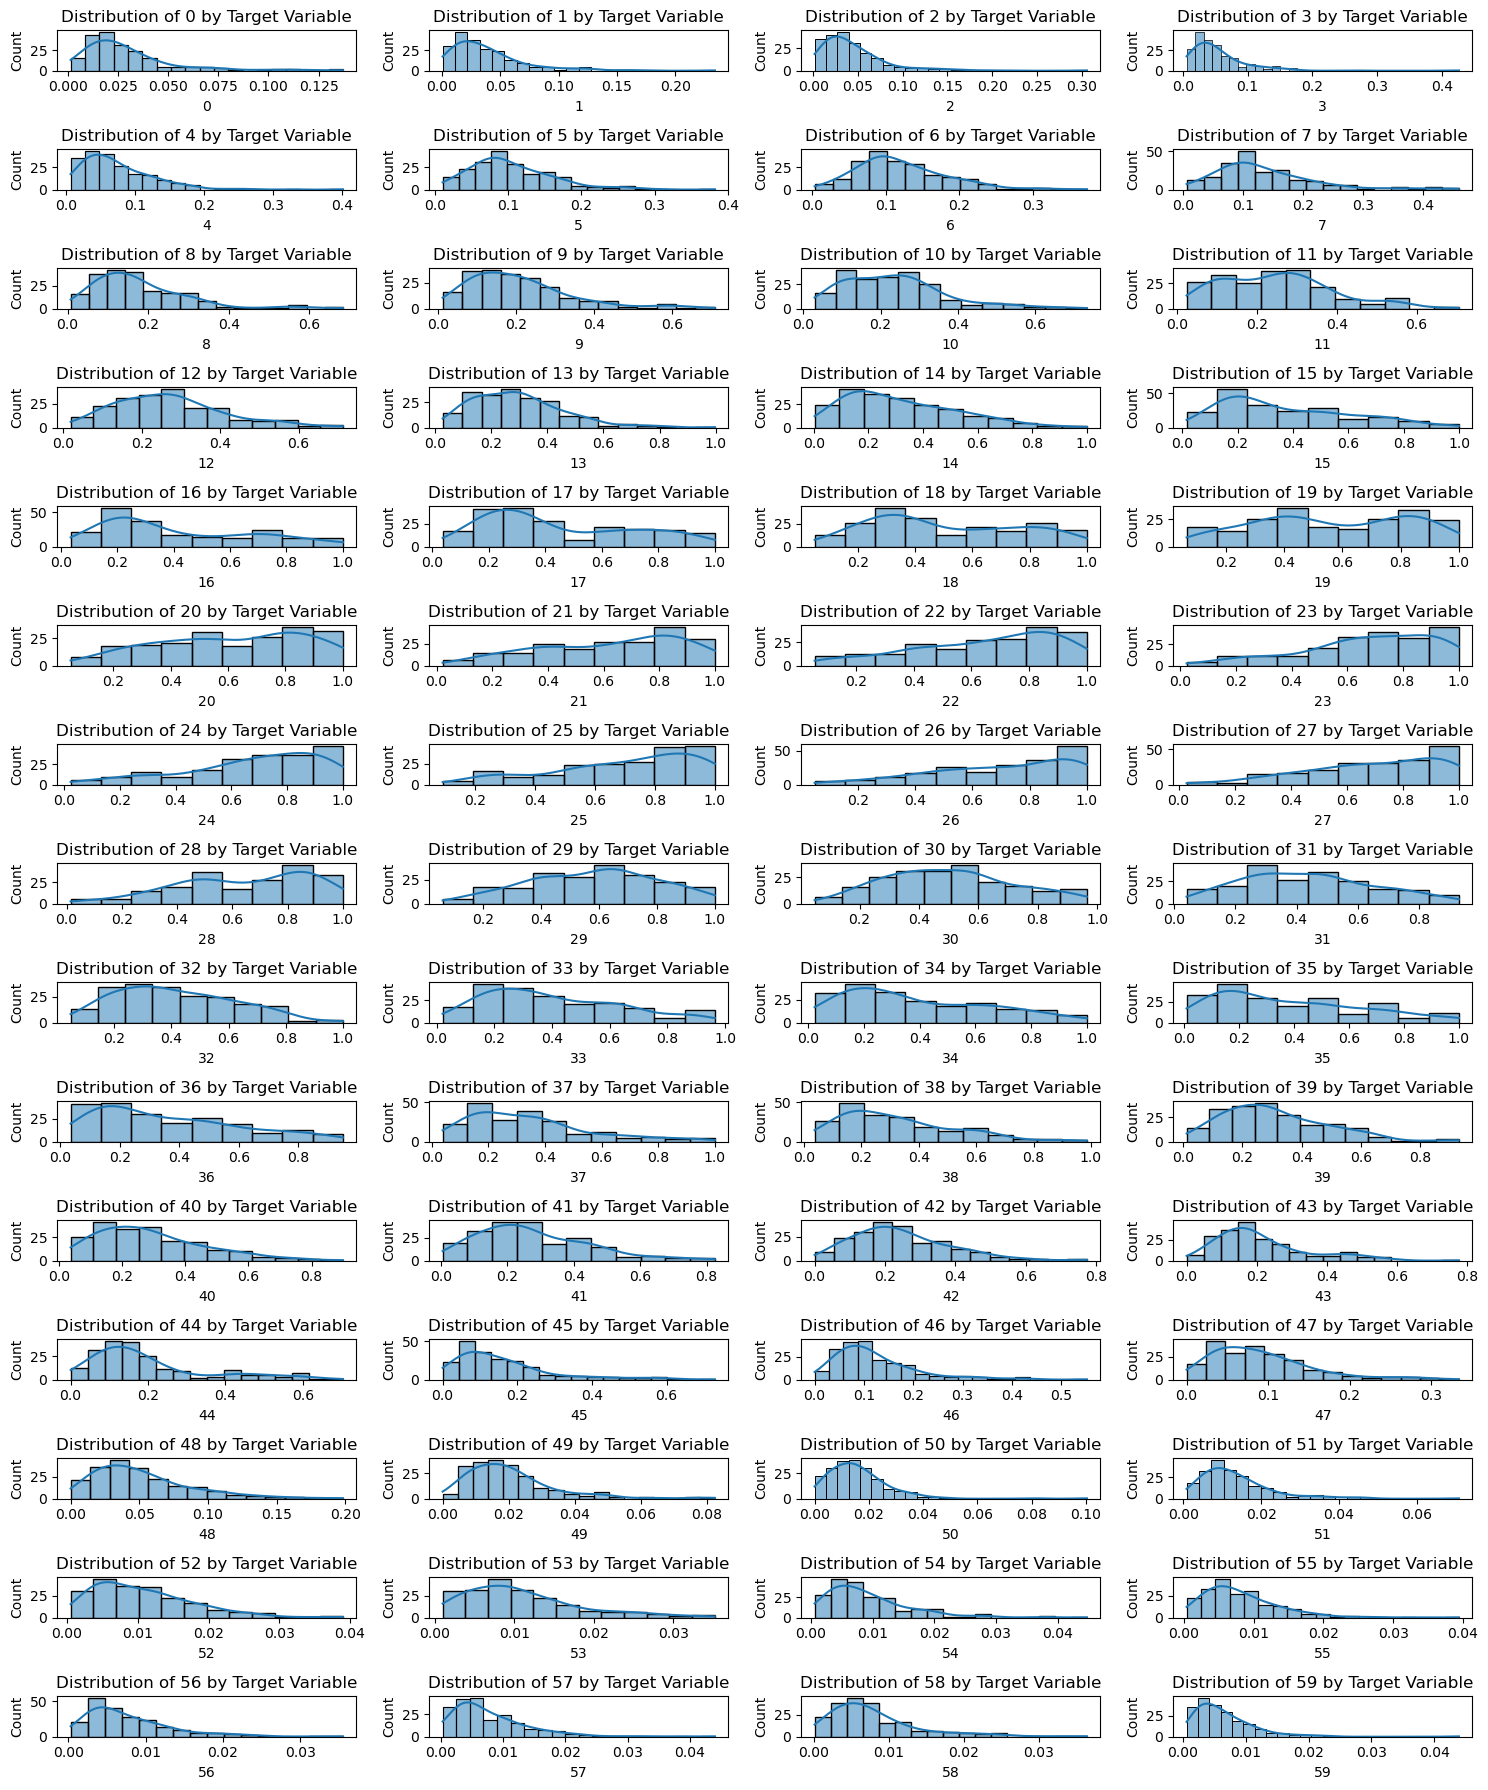

In [26]:
 # uing subplots to display distribution of each feature by target variable


fig, axes = plt.subplots(15, 4, figsize=(15, 18))
axes = axes.flatten()

for i,col in enumerate(df.columns[:-1]):
    sns.histplot(data=df, x=col,  ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {col} by Target Variable")
plt.tight_layout()
plt.show()

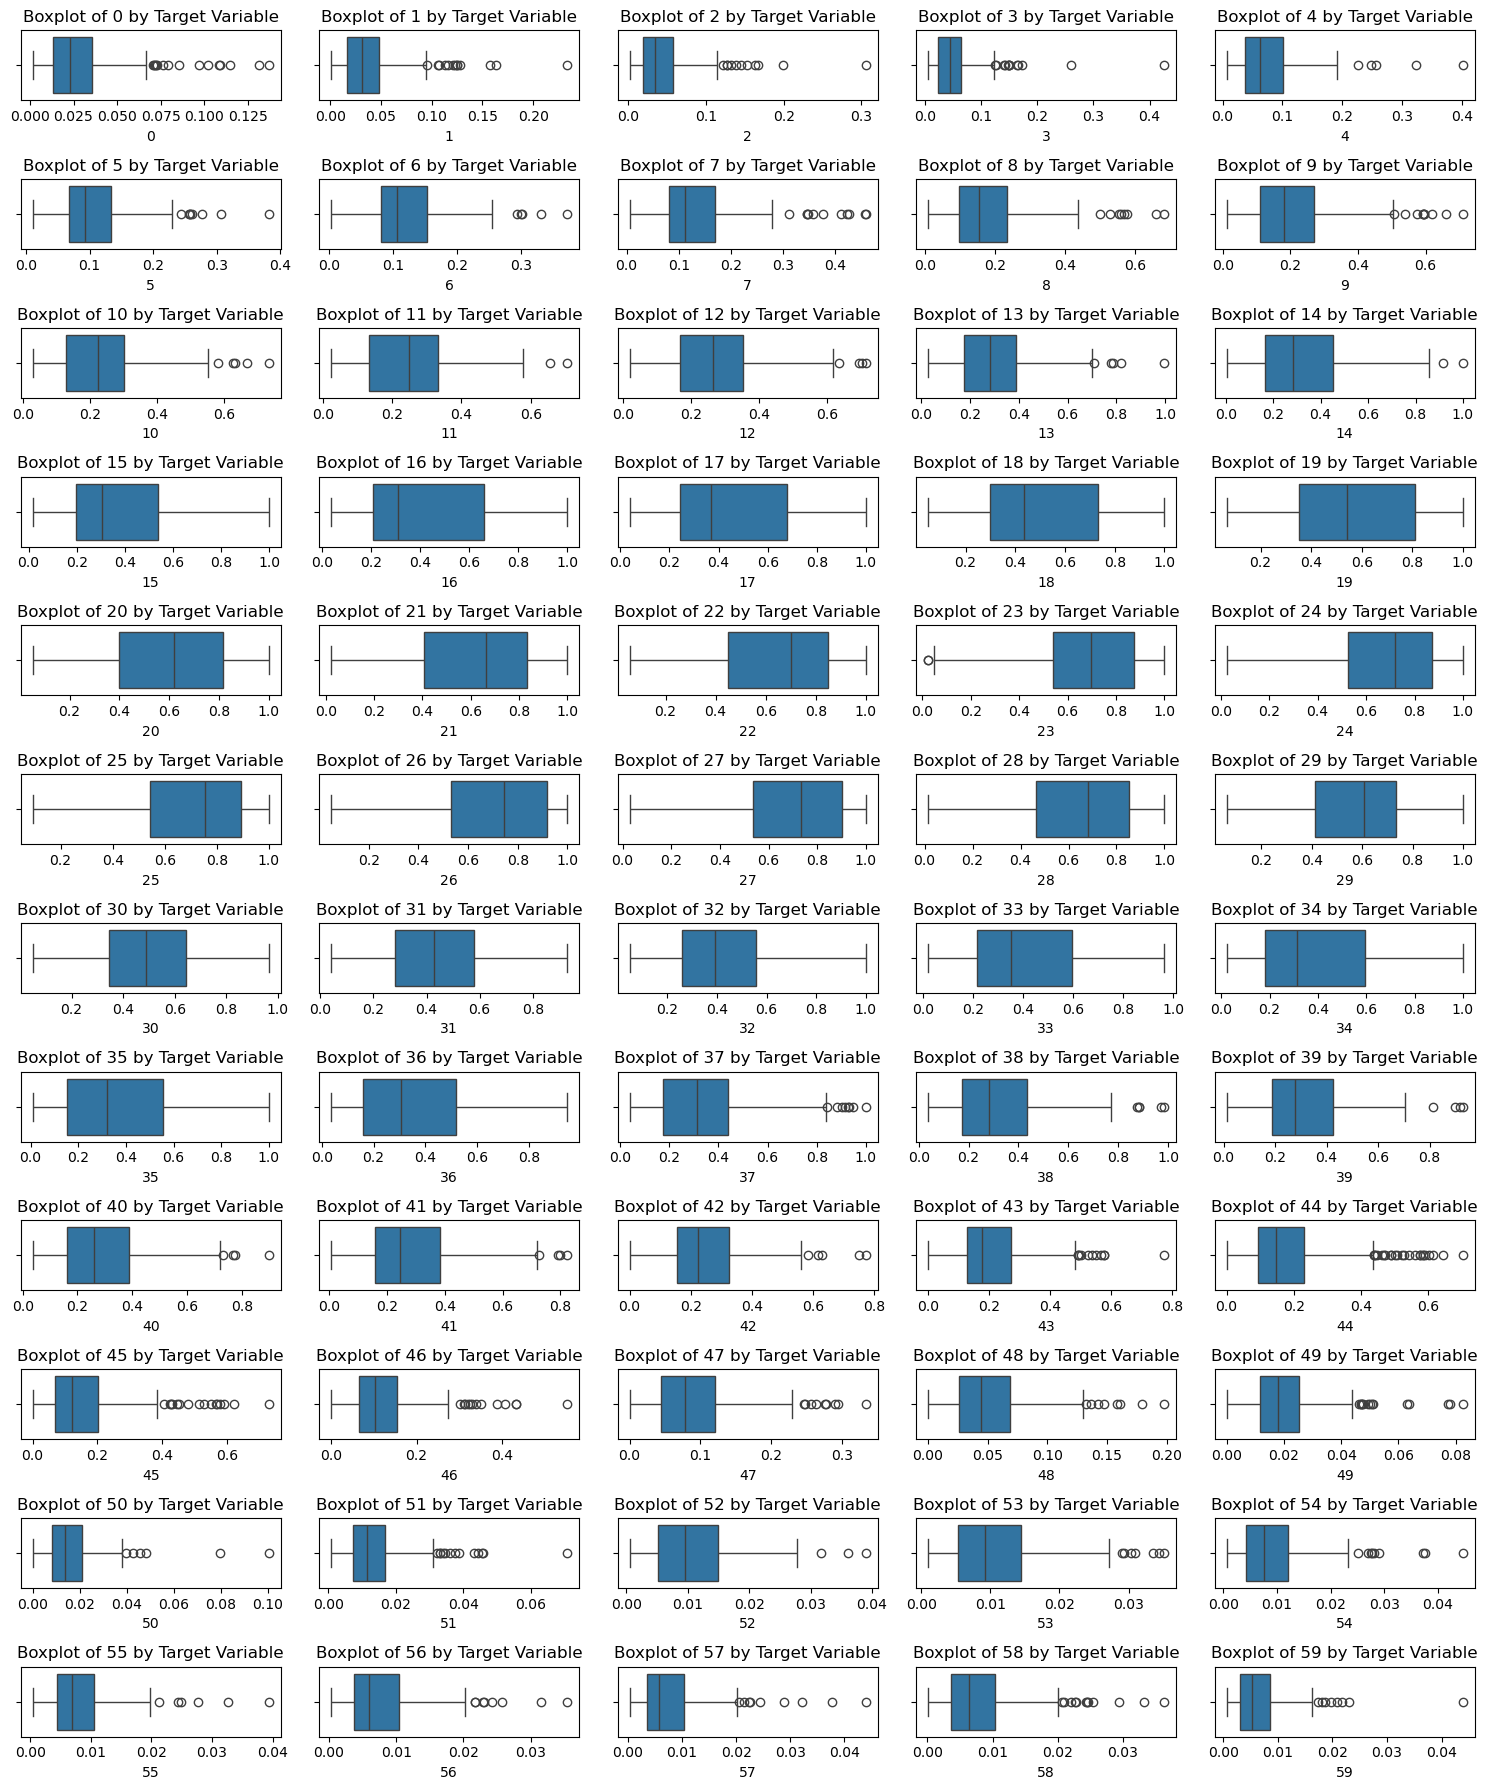

In [30]:
#boxplots to display distribution of each feature by target variable
# identify outliers using boxplots  
fig, axes = plt.subplots(12, 5, figsize=(15, 18))
axes = axes.flatten()

for i,col in enumerate(df.columns[:-1] ):
    sns.boxplot(x=df[col], data=df, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} by Target Variable")
plt.tight_layout()
plt.show()
   

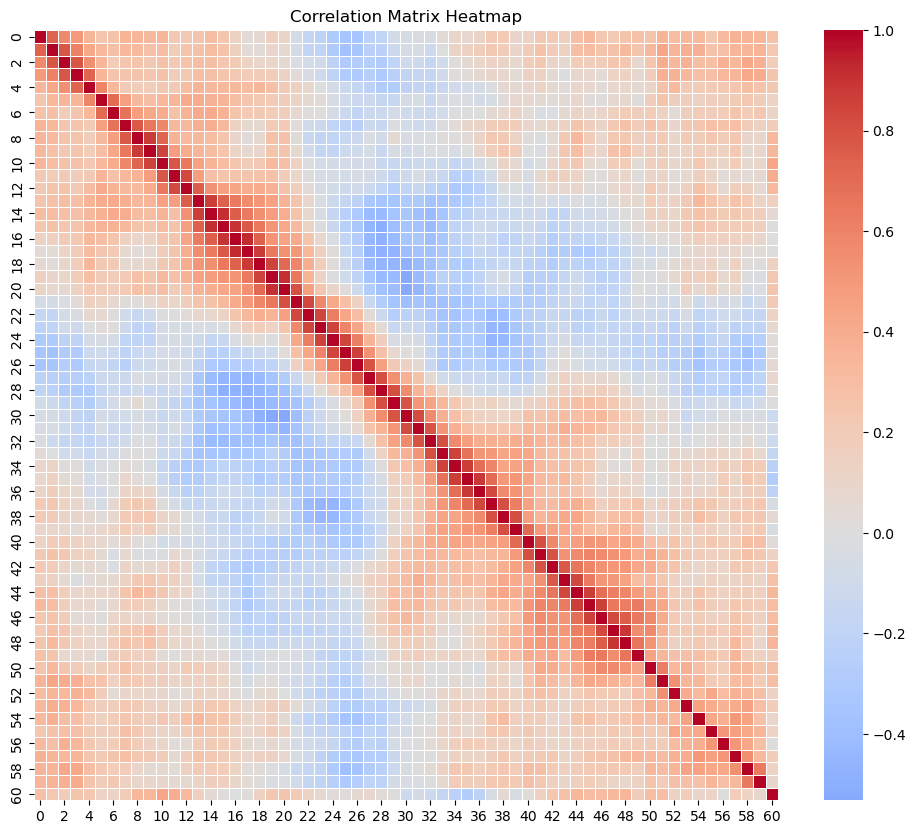

In [32]:
# create  heatmap of correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5, center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()